# 04 Statistical Analysis: Diabetic Readmission Factors

This notebook contains a detailed statistical analysis of the diabetic patient dataset, focusing on identifying the clinical and demographic drivers of 30-day hospital readmissions.

### Analysis Scope:
1. **Descriptive Statistics**: Summary of key numerical features.
2. **Categorical Analysis**: Frequency distributions of demographics and clinical markers.
3. **Correlation Analysis**: Identifying strongest predictors of readmission.
4. **Outlier Detection**: Using IQR and Z-scores for clinical anomalies.
5. **Comparative Analysis**: Profiling Readmitted vs. Not Readmitted populations.
6. **Deep Pattern Discovery**: Multi-factor risk analysis.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().resolve().name == 'notebooks' else Path.cwd().resolve()
DATA_PATH = PROJECT_ROOT / 'data/processed/diabetic_data_clean.csv'

df = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Dataset Loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")

Dataset Loaded: 69,990 rows, 48 columns


## 1. Descriptive Statistics
Providing a baseline understanding of the central tendencies and spread of key numerical clinical features.

In [3]:
num_cols = ['age', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 
            'num_medications', 'number_diagnoses', 'number_outpatient', 
            'number_emergency', 'number_inpatient']

stats_table = df[num_cols].describe().T
stats_table['skewness'] = df[num_cols].skew()
display(stats_table.round(2))

,count,mean,std,min,25%,50%,75%,max,skewness
age,69990.0,65.44,15.97,5.0,55.0,65.0,75.0,95.0,-0.63
time_in_hospital,69990.0,4.27,2.93,1.0,2.0,3.0,6.0,14.0,1.18
num_lab_procedures,69990.0,42.88,19.89,1.0,31.0,44.0,57.0,132.0,-0.22
num_procedures,69990.0,1.43,1.76,0.0,0.0,1.0,2.0,6.0,1.23
num_medications,69990.0,15.67,8.29,1.0,10.0,14.0,20.0,81.0,1.43
number_diagnoses,69990.0,7.22,2.00,1.0,6.0,8.0,9.0,16.0,-0.72
number_outpatient,69990.0,0.28,1.06,0.0,0.0,0.0,0.0,42.0,9.70
number_emergency,69990.0,0.10,0.51,0.0,0.0,0.0,0.0,42.0,21.23
number_inpatient,69990.0,0.18,0.60,0.0,0.0,0.0,0.0,12.0,5.59


### Visualizing Distributions
Analyzing skewness and spread for critical indicators.

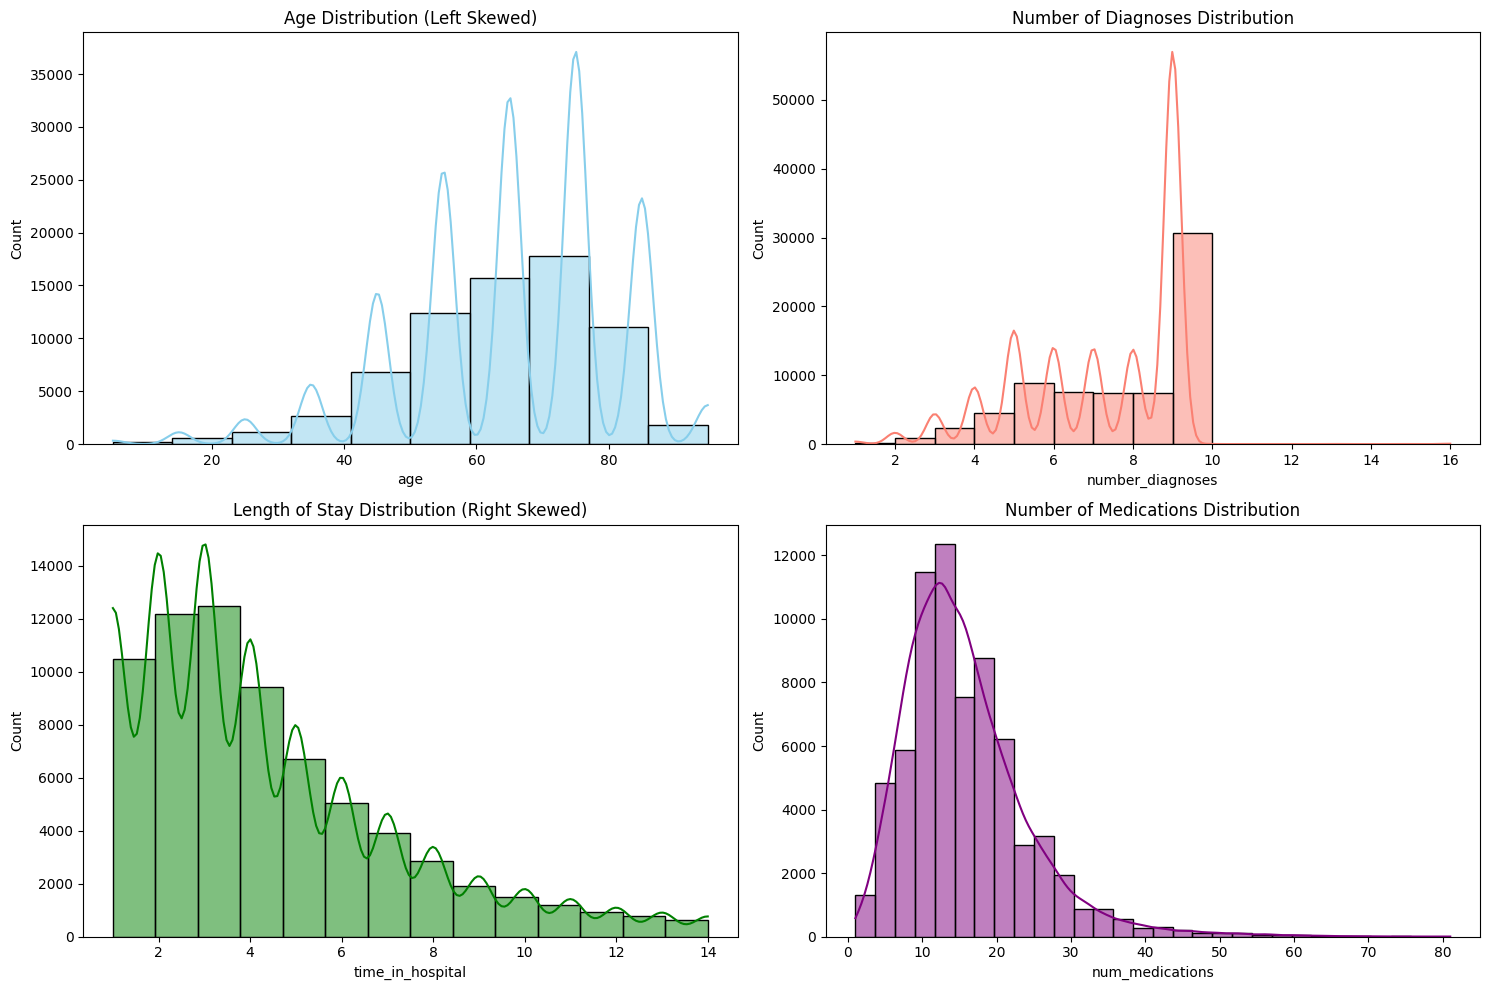

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.histplot(df['age'], bins=10, kde=True, ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Age Distribution (Left Skewed)')

sns.histplot(df['number_diagnoses'], bins=15, kde=True, ax=axes[0,1], color='salmon')
axes[0,1].set_title('Number of Diagnoses Distribution')

sns.histplot(df['time_in_hospital'], bins=14, kde=True, ax=axes[1,0], color='green')
axes[1,0].set_title('Length of Stay Distribution (Right Skewed)')

sns.histplot(df['num_medications'], bins=30, kde=True, ax=axes[1,1], color='purple')
axes[1,1].set_title('Number of Medications Distribution')

plt.tight_layout()
plt.show()

## 2. Categorical Analysis
Identifying dominant categories and imbalance in non-numerical features.

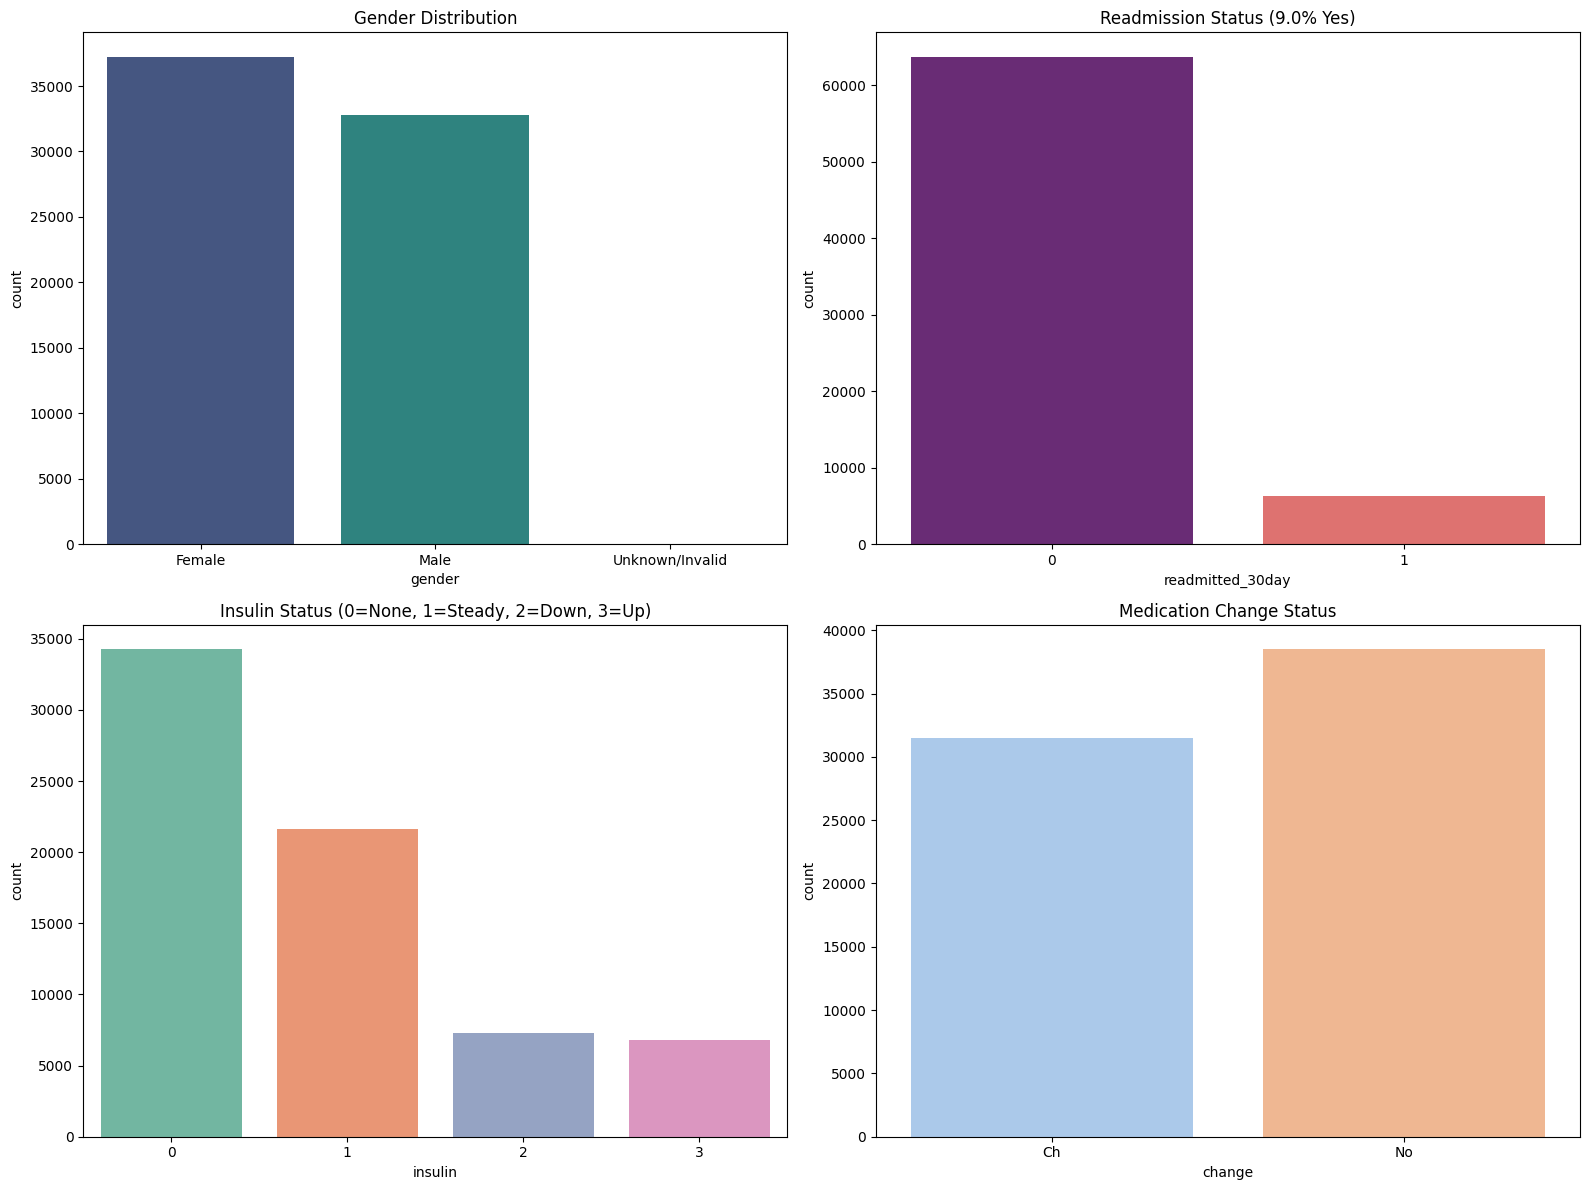

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.countplot(data=df, x='gender', ax=axes[0,0], palette='viridis')
axes[0,0].set_title('Gender Distribution')

sns.countplot(data=df, x='readmitted_30day', ax=axes[0,1], palette='magma')
axes[0,1].set_title('Readmission Status (9.0% Yes)')

sns.countplot(data=df, x='insulin', ax=axes[1,0], palette='Set2')
axes[1,0].set_title('Insulin Status (0=None, 1=Steady, 2=Down, 3=Up)')

sns.countplot(data=df, x='change', ax=axes[1,1], palette='pastel')
axes[1,1].set_title('Medication Change Status')

plt.tight_layout()
plt.show()

## 3. Correlation Analysis
Quantifying the linear relationship between features and the target variable (30-day Readmission).

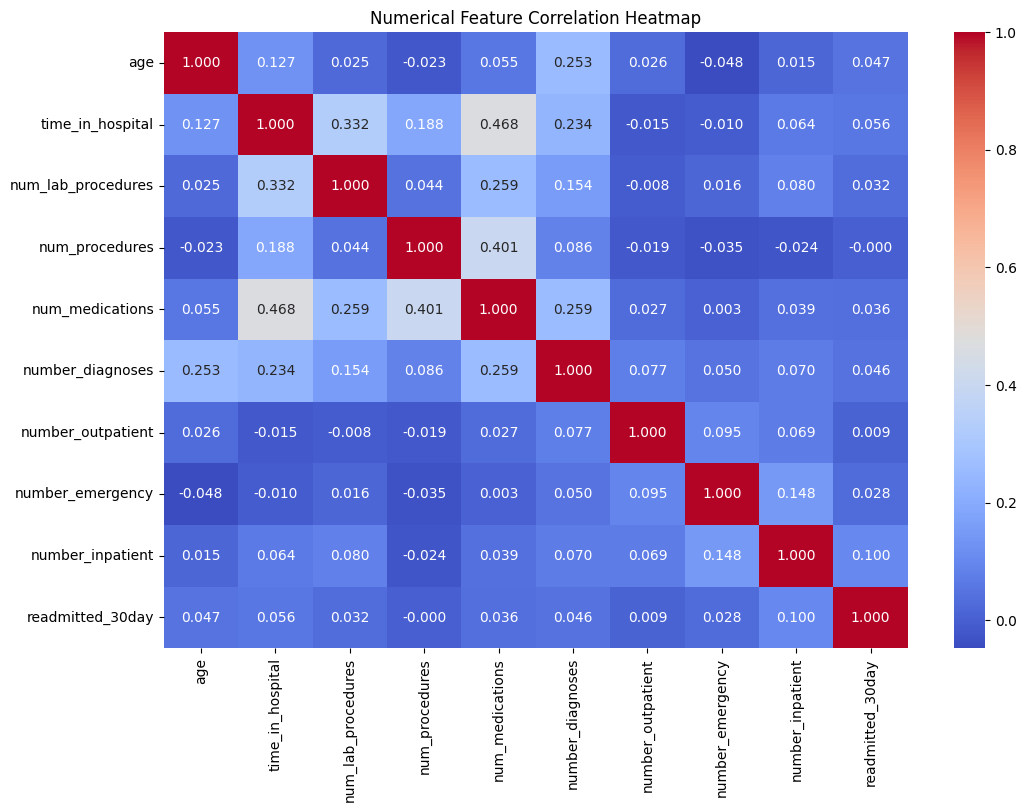

Top Correlations with Readmission:
readmitted_30day      1.000000
number_inpatient      0.100278
time_in_hospital      0.055824
age                   0.047077
number_diagnoses      0.045610
num_medications       0.036198
num_lab_procedures    0.032063
number_emergency      0.028022
number_outpatient     0.008633
num_procedures       -0.000280
Name: readmitted_30day, dtype: float64


In [6]:
# Pre-processing for correlation
corr_df = df[num_cols + ['readmitted_30day']].copy()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm', fmt='.3f')
plt.title('Numerical Feature Correlation Heatmap')
plt.show()

print("Top Correlations with Readmission:")
print(corr_df.corr()['readmitted_30day'].sort_values(ascending=False))

## 4. Outlier Detection
Identifying clinical anomalies that may represent extremely high-risk cases.

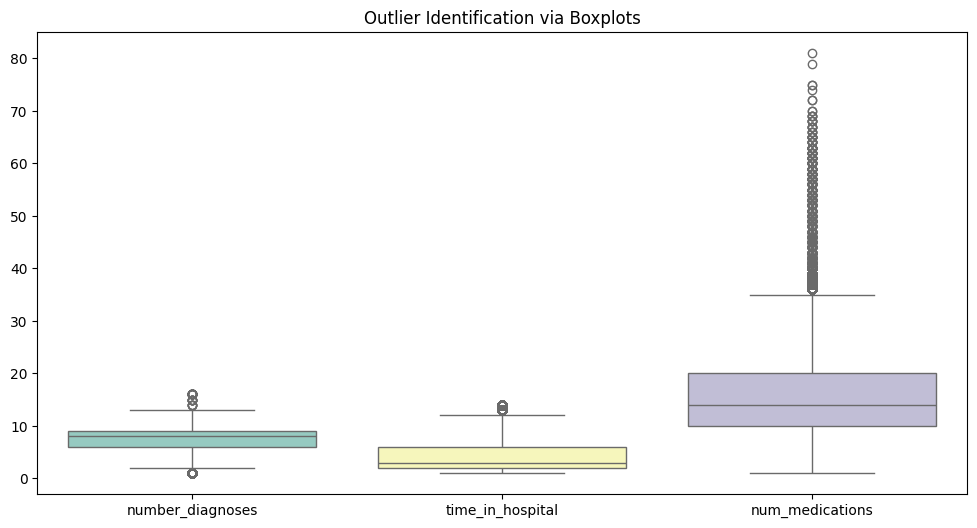

number_diagnoses: Found 235 outliers (0.34%)
time_in_hospital: Found 1403 outliers (2.00%)
num_medications: Found 1868 outliers (2.67%)


In [7]:
cols_to_check = ['number_diagnoses', 'time_in_hospital', 'num_medications']

plt.figure(figsize=(12, 6))
sns.boxplot(data=df[cols_to_check], palette='Set3')
plt.title('Outlier Identification via Boxplots')
plt.show()

for col in cols_to_check:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR))]
    print(f"{col}: Found {len(outliers)} outliers ({len(outliers)/len(df)*100:.2f}%)")

## 5. Comparative Analysis: Readmitted vs Not Readmitted
Determining what makes readmitted patients different from the general population.

In [8]:
comparison = df.groupby('readmitted_30day')[num_cols].mean().T
comparison.columns = ['Not Readmitted', 'Readmitted']
comparison['% Difference'] = ((comparison['Readmitted'] - comparison['Not Readmitted']) / comparison['Not Readmitted']) * 100

display(comparison.round(3))

print("\nStatistical Significance (T-Tests):")
for col in num_cols:
    r0 = df[df['readmitted_30day']==0][col]
    r1 = df[df['readmitted_30day']==1][col]
    t_stat, p_val = stats.ttest_ind(r0, r1)
    print(f"{col:20s}: p-value = {p_val:.6f} {'***' if p_val < 0.001 else '*'}")

,Not Readmitted,Readmitted,% Difference
age,65.207,67.837,4.034
time_in_hospital,4.222,4.795,13.570
num_lab_procedures,42.675,44.906,5.228
num_procedures,1.426,1.424,-0.121
num_medications,15.571,16.620,6.739
number_diagnoses,7.195,7.515,4.437
number_outpatient,0.277,0.309,11.613
number_emergency,0.099,0.150,50.472
number_inpatient,0.157,0.368,134.134



Statistical Significance (T-Tests):
age                 : p-value = 0.000000 ***
time_in_hospital    : p-value = 0.000000 ***
num_lab_procedures  : p-value = 0.000000 ***
num_procedures      : p-value = 0.940967 *
num_medications     : p-value = 0.000000 ***
number_diagnoses    : p-value = 0.000000 ***
number_outpatient   : p-value = 0.022369 *
number_emergency    : p-value = 0.000000 ***
number_inpatient    : p-value = 0.000000 ***


## 6. Deep Pattern Discovery
Combining factors to identify high-risk personas.

In [9]:
print("1. Pattern: Elderly (70+) + Many Diagnoses (>=7)")
mask = (df['age'] >= 70) & (df['number_diagnoses'] >= 7)
rate = df[mask]['readmitted_30day'].mean() * 100
print(f"   Readmission Rate: {rate:.2f}% (vs 9.0% baseline)")

print("\n2. Pattern: Prior Inpatient Visits (>=2)")
mask = (df['number_inpatient'] >= 2)
rate = df[mask]['readmitted_30day'].mean() * 100
print(f"   Readmission Rate: {rate:.2f}% (Significant Risk Indicator)")

print("\n3. Pattern: Insulin Change during stay")
rate = df[df['insulin'].isin([2, 3])]['readmitted_30day'].mean() * 100
print(f"   Readmission Rate: {rate:.2f}% (Indicates metabolic instability)")

1. Pattern: Elderly (70+) + Many Diagnoses (>=7)
   Readmission Rate: 10.73% (vs 9.0% baseline)

2. Pattern: Prior Inpatient Visits (>=2)
   Readmission Rate: 21.49% (Significant Risk Indicator)

3. Pattern: Insulin Change during stay
   Readmission Rate: 10.20% (Indicates metabolic instability)
